# **FinBERT Sentiment Scoring**

本 notebook 使用 [FinBERT](https://huggingface.co/ProsusAI/finbert)（一个在金融文本上微调的 BERT 模型）从 StockNet 推文中提取情感特征。股价不仅受基本面和技术面驱动，还受市场情绪的显著影响。Twitter 上的金融讨论能够近实时地反映散户投资者的情绪变化。通过将推文情感量化为结构化特征，我们为下游 LSTM 模型提供了价格历史之外的额外信息通道。

In [1]:
import os
import matplotlib.pyplot as plt

import json
import pandas as pd
from tqdm import tqdm

TWEET_DIR = os.path.join('..', 'Data', 'tweet', 'preprocessed')
CACHE_DIR = os.path.join('..', 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'Tweet directory: {TWEET_DIR}')
print(f'Cache directory: {CACHE_DIR}')

Tweet directory: ../Data/tweet/preprocessed
Cache directory: ../cache


## **步骤一: 加载与还原推文文本**

StockNet 将推文存储为**预分词的 JSON 数组**，其中 `@用户名` 和链接被匿名化为 `AT_USER` 和 `URL` 占位符：

```json
{"text": ["rt", "AT_USER", "here's", "how", "apple", "could", "be", "making", "a", "huge", "push", "into", "healthcare", "-->", "URL", "$", "aapl"], "created_at": "Thu Jan 02 04:31:32 +0000 2014", "user_id_str": "1653399757"}
```

预处理步骤：
- **拼接 tokens**：通过 `" ".join(tokens)` 还原为完整句子
- **去除占位符**：`AT_USER` 和 `URL` 不携带情感信息，保留它们可能干扰 FinBERT 的判断

以上面这条推文为例：
- 清洗前：`rt AT_USER here's how apple could be making a huge push into healthcare --> URL $ aapl`
- 清洗后：`rt here's how apple could be making a huge push into healthcare --> $ aapl`

In [2]:
def load_all_tweets(tweet_dir):
    """Load all preprocessed tweets and reconstruct text."""
    records = []
    stocks = [s for s in sorted(os.listdir(tweet_dir)) if not s.startswith('.')]

    for stock in tqdm(stocks, desc='Loading stocks'):
        stock_dir = os.path.join(tweet_dir, stock)
        if not os.path.isdir(stock_dir):
            continue
        for date_file in sorted(os.listdir(stock_dir)):
            if date_file.startswith('.'):
                continue
            with open(os.path.join(stock_dir, date_file)) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    tokens = [t for t in json.loads(line)['text']
                              if t not in ('AT_USER', 'URL')]
                    text = ' '.join(tokens).strip()
                    if text:
                        records.append({'stock': stock, 'date': date_file, 'text': text})

    df = pd.DataFrame(records)
    print(f'Loaded {len(df)} tweets from {df["stock"].nunique()} stocks')
    print(f'Date range: {df["date"].min()} to {df["date"].max()}')
    return df

tweets_df = load_all_tweets(TWEET_DIR)
pd.set_option('display.max_colwidth', None)
tweets_df.head()

Loading stocks: 100%|███████████████████████████| 87/87 [00:02<00:00, 41.80it/s]

Loaded 106336 tweets from 87 stocks
Date range: 2014-01-01 to 2015-12-31


,stock,date,text
0,AAPL,2014-01-01,rt summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - -
1,AAPL,2014-01-01,rt summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - -
2,AAPL,2014-01-01,itv will boost apple $ aapl apple
3,AAPL,2014-01-01,"iphone users are more intelligent than samsung , blackberry and htc owners , $ aapl $ bbry ,"
4,AAPL,2014-01-01,rt summary of yesterday's webcast featuring $ aapl $ wynn $ goog $ lgf tradereducation options hedgingstrategies - -


## **步骤二：推文清洗**

原始数据中存在大量**完全重复的推文文本**，主要来自三个渠道：

- **数据的提取：** 抓取过程中同一条推文被多次写入文件。
- **机器人刷帖：** 金融 cashtag 流（如 `$AAPL`）常被推广账号污染——同一条模板化推文（往往同时堆叠 `$AAPL $GOOG $LGF` 等多个 ticker）被反复发送以最大化曝光。
- **转发（rt）：** 同一条消息被多个用户转发。

**为什么必须去重？** 下一步会把每个 stock-day 的逐条情感压缩为 `mean / median / min / max` 等统计量，并以 `tweet_count` 作为关注度代理。重复推文将导致：

- **情感统计被污染：** 一条被刷 N 次的推文会把当天的 `mean` 强行拉向它自身的情感，使"情绪倾向"被"消息热度"扭曲。
- **关注度被虚高：** `tweet_count` 会把刷量混入真实讨论量，丧失作为关注度信号的意义。

**方法：**在 `(stock, date, text)` 粒度上去重，即**同一只股票、同一天内文本完全相同的推文只保存一条**。选择 stock-day 粒度而非全局，是因为后续聚合的基本单元就是 stock-day。同一条文本若出现在不同交易日，应视为各自那天的独立信号予以保留。

**取舍说明：**文本去重会把不同用户自发转发的同一条消息也合并为一条。考虑到 cashtag 流中机器人刷帖通常远多于有效转发，因此将重复一律视为**噪声**而非情绪放大信号。

去重: 106336 → 92212 (删除 14124, 13.3%)


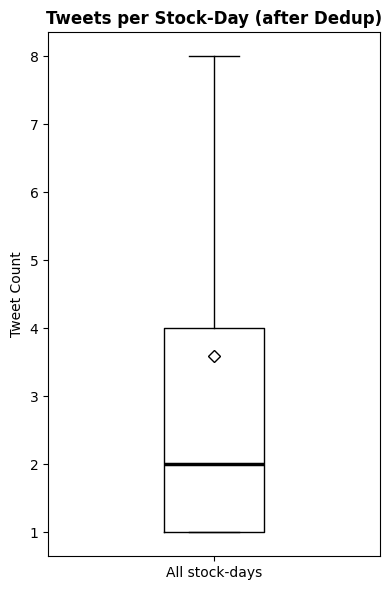

count    25711.000000
mean         3.586480
std          5.928346
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        282.000000


In [3]:
def dedup_tweets(df, subset=('stock', 'date', 'text')):
    """按 (stock, date, text) 去重，打印摘要并返回去重后的 DataFrame。"""
    n_before = len(df)
    out = df.drop_duplicates(subset=list(subset)).reset_index(drop=True)
    removed = n_before - len(out)
    print(f'去重: {n_before} → {len(out)} (删除 {removed}, {removed / n_before:.1%})')
    return out


def plot_daily_tweet_distribution(df, ax=None):
    """绘制所有 stock-day 推文数的箱线图，返回每日计数 Series。"""
    daily_counts = df.groupby(['stock', 'date']).size()
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 6))

    ax.boxplot(
        daily_counts.values,
        widths=0.3,
        showfliers=False,
        showmeans=True,
        medianprops=dict(color='black', linewidth=2.5),
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='black', markersize=6),
    )
    ax.set_title('Tweets per Stock-Day (after Dedup)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Tweet Count')
    ax.set_xticks([1])
    ax.set_xticklabels(['All stock-days'])
    return daily_counts

tweets_df = dedup_tweets(tweets_df)
daily_counts = plot_daily_tweet_distribution(tweets_df)

plt.tight_layout()
plt.show()

print(daily_counts.describe().to_string())

## **步骤三: FinBERT 情感推理**

我们使用 **FinBERT**（`ProsusAI/finbert`）进行情感分类。相比通用情感模型（如 VADER、TextBlob），FinBERT 有两个关键优势：

1. **领域专用**：在约 50,000 条金融新闻语句上微调，能理解 *"revenue beat expectations"* 是正面、*"downgraded to sell"* 是负面——这些是通用模型常常误判的金融语义。
2. **软概率输出**：模型输出的不是硬标签，而是三个类别（**positive / negative / neutral**）的概率分布，保留了不确定性信息，有利于构建更丰富的下游特征。

每条推文经 tokenizer 编码（最大长度 128 tokens）后送入模型，对 logits 施加 softmax 得到三个概率值。推理采用 batch 方式（batch_size=64）以提升效率。

In [4]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load FinBERT model
MODEL_NAME = 'ProsusAI/finbert'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Use GPU/MPS if available
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = model.to(device)
model.eval()
print(f'Using device: {device}')
print(f'Model labels: {model.config.id2label}')

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 41052.55it/s]

Using device: mps
Model labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [5]:
def run_finbert_inference(texts, tokenizer, model, device, batch_size=64, max_length=128):
    """Run FinBERT inference on a list of texts. Returns (pos, neg, neu) scores."""
    all_scores = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc='FinBERT inference'):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        
        all_scores.append(probs)
    
    return np.vstack(all_scores)

# FinBERT label order: positive=0, negative=1, neutral=2
# Verify from model config
print(f'Label mapping: {model.config.id2label}')

Label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [6]:
# Run inference (this takes ~1-3 hours on CPU, ~15-30 min on GPU)
sentiment_cache_path = os.path.join(CACHE_DIR, 'sentiment_scores.pkl')

if os.path.exists(sentiment_cache_path):
    print('Loading cached sentiment scores...')
    sentiment_df = pd.read_pickle(sentiment_cache_path)
else:
    texts = tweets_df['text'].tolist()
    scores = run_finbert_inference(texts, tokenizer, model, device, batch_size=64)
    
    # Map columns based on model's label order
    label_map = model.config.id2label  # {0: 'positive', 1: 'negative', 2: 'neutral'}
    col_names = [label_map[i] for i in range(3)]
    
    sentiment_df = tweets_df[['stock', 'date']].copy()
    for idx, name in enumerate(col_names):
        sentiment_df[name] = scores[:, idx]
    
    # Save cache
    sentiment_df.to_pickle(sentiment_cache_path)
    print(f'Saved sentiment scores to {sentiment_cache_path}')

print(f'Sentiment DataFrame shape: {sentiment_df.shape}')
sentiment_df.head()

FinBERT inference: 100%|████████████████████| 1441/1441 [19:44<00:00,  1.22it/s]

Saved sentiment scores to ../cache/sentiment_scores.pkl
Sentiment DataFrame shape: (92212, 5)


,stock,date,positive,negative,neutral
0,AAPL,2014-01-01,0.035833,0.022306,0.941862
1,AAPL,2014-01-01,0.742327,0.010116,0.247557
2,AAPL,2014-01-01,0.254123,0.009905,0.735972
3,AAPL,2014-01-01,0.067334,0.018531,0.914135
4,AAPL,2014-01-01,0.073543,0.178964,0.747493


**缓存：** FinBERT 推理是整个流程中最耗时的步骤。推理结果保存至 `cache/sentiment_scores.pkl`，后续重跑时直接加载缓存，跳过推理。

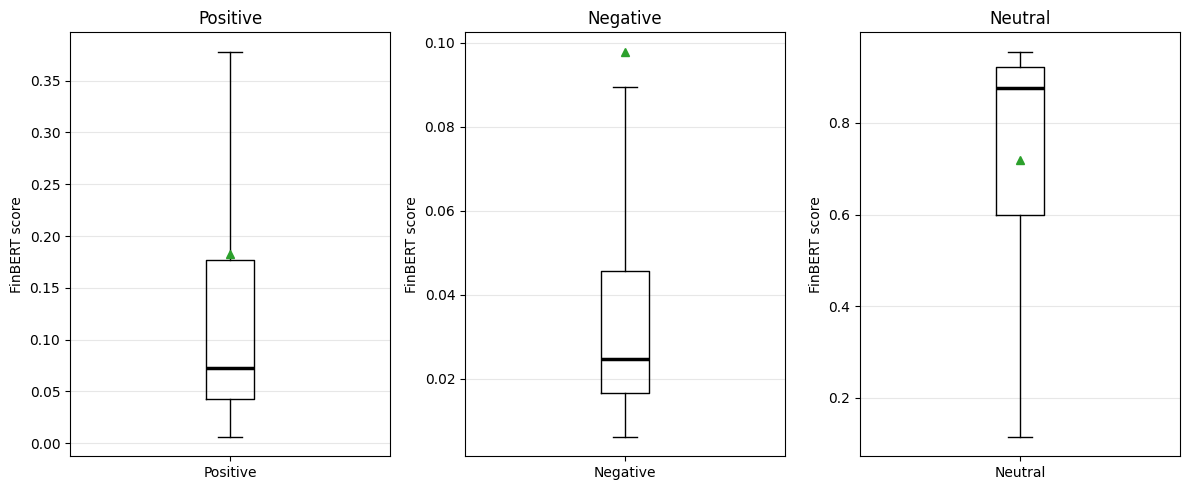

In [21]:
cols   = ['positive', 'negative', 'neutral']
titles = ['Positive', 'Negative', 'Neutral']

bw = dict(color='black')   

fig, axes = plt.subplots(1, 3, figsize=(12, 5))   
for ax, col, title in zip(axes, cols, titles):
    ax.boxplot(
        sentiment_df[col],
        showfliers=False,
        showmeans=True,
        boxprops=bw,
        whiskerprops=bw,
        capprops=bw,
        medianprops=dict(color='black', linewidth=2.5),
    )
    ax.set_xticklabels([title])
    ax.set_ylabel('FinBERT score')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_boxplot_3panel.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [17]:
def show_top_tweets(sentiment_df, tweets_df,
                    sentiments=('positive', 'negative', 'neutral'),
                    top_n=5, max_colwidth=300):
    """每个情感类别展示得分最高的 top_n 条推文,返回带 text 的合并结果。"""
    assert len(sentiment_df) == len(tweets_df), "行数对不上,text 无法对齐"

    results = sentiment_df.copy()
    results['text'] = tweets_df['text']

    pd.set_option('display.max_colwidth', max_colwidth)
    for sentiment in sentiments:
        print(f'\n=== TOP {top_n} {sentiment.upper()} ===')
        display(results.nlargest(top_n, sentiment)[['stock', 'date', sentiment, 'text']])

    return results

results = show_top_tweets(sentiment_df, tweets_df)


=== TOP 5 POSITIVE ===


,stock,date,positive,text
85481,UNH,2015-07-16,0.960782,$ unh optum revenues grew 16 % in q2 . operating margin of 6.4 % improved yoy with all businesses improving their margins sequentially . unhq 2
85382,UNH,2015-04-17,0.960195,"rt $ unh unitedhealthcare revenues grew 11.5 % to $ 32.6 billion in q1 , with operating margin improved to 5.8 % yoy unhq 1"
85482,UNH,2015-07-16,0.960030,"$ unh unitedhealthcare q2 revenues grew 10 % to $ 33.1 billion , with operating margins steady at 6.1 % . unhq 2"
88487,WFC,2014-01-13,0.959980,$ wfc's cash flows improved more than any other banks ’ because of focus on lending & mortgage financing activities
32866,CELG,2015-10-12,0.959261,rt $ celg improvements in pasi scores and disease-related quality of life maintained at week 52 - otezla



=== TOP 5 NEGATIVE ===


,stock,date,negative,text
73089,ORCL,2015-06-17,0.976390,"rt $ orcl 4q15 pr : total revenues were $ 10.7 bil , down 5 % vs . $ 11.3 bil in 4q14 . net income $ 2.8 bil vs . $ 3.6 bil in 4q14 ."
65775,MCD,2014-01-23,0.976098,"for the year , mcdonald's customer traffic in the us was down 1.6 % ( per 8 - k filing ) $ mcd"
77429,PG,2014-01-24,0.976071,p & g's $ 3.4 b profit is down 16 % from 2q a year ago . $ pg
62681,JPM,2015-02-24,0.975917,$ jpm mortgage headcount 27k in 2014 down from 35k in 2013
66123,MCD,2014-09-09,0.975878,mcdonald's ( $ mcd ) global sss fell 3.7 % in august



=== TOP 5 NEUTRAL ===


,stock,date,neutral,text
90752,XOM,2014-01-29,0.955430,$ xom company update : exxon mobil corporation ( nyse : xom ) – exxon mobil ... : company update : exxon mobil corpor ...
60939,JNJ,2014-10-08,0.955414,agreed . however is a subsidiary of $ jnj and
17547,AMZN,2014-03-13,0.955150,rt amazon prime members will pay $ 99 per year on their annual renewal date and amazon student members will pay $ 49 . $ amzn
7298,AAPL,2015-01-27,0.955149,alphastuff for $ aapl $ twtr $ goog $ msft $ nflx will all be broadcast from a cdn using the account sm
55155,GOOG,2015-01-27,0.955149,alphastuff for $ aapl $ twtr $ goog $ msft $ nflx will all be broadcast from a cdn using the account sm


## 步骤三: 情感特征聚合

每只股票每天可能有多条推文，我们需要将其压缩为固定维度的特征向量。对 positive / negative / neutral 三个情感维度分别计算四种统计量：

| 统计量 | 含义 |
|--------|------|
| **mean** | 当日整体情感倾向 |
| **median** | 稳健的中心趋势，对极端值不敏感 |
| **min** | 捕捉当日最悲观/最保守的信号 |
| **max** | 捕捉当日最乐观/最极端的信号 |

每个情感维度产出 4 个统计量，共 **3 × 4 = 12 维**情感特征。

此外加入一维**相对推文量**作为关注度的代理指标。这里刻意不使用当日推文的**绝对数量**：在跨股票池化的设定下，苹果、特斯拉等热门标的的讨论量天然远高于中小盘，绝对计数会退化成"这是哪只股票"的身份代理，而非我们想要的"今日是否有重大事件"信号。

因此改用**异常放量比值**，即当日推文量相对于该股自身近期基线的倍数：

$$\text{rel\_volume}_t = \frac{\text{tweet\_count}_t}{\text{MA}(\text{tweet\_count},\ \text{过去 } N \text{ 天})}$$

比值 > 1 表示当日讨论量显著高于该股近期水平，往往对应财报、突发新闻等事件。它同时隐含了**可靠性权重**：计数过低的 stock-day，其 12 维情感统计量噪声较大。

> ⚠️ 滚动均值仅使用 **t 时刻之前**的数据计算（rolling window），避免引入未来信息（look-ahead bias）。

因此，**s共产出 14 维特征**：3 情感类别 × 4 统计量 + 1 绝对推文量 + 1 相对推文量。

In [11]:
def aggregate_daily_sentiment(sentiment_df, vol_window=20, vol_min_periods=5):
    """Aggregate per-tweet sentiment to daily features.

    - 12 sentiment stats: mean/median/min/max for positive/negative/neutral
    - rel_volume: today's tweet count relative to this stock's OWN recent baseline
      (rolling mean over the past `vol_window` stock-days, excluding today)
    """
    grouped = sentiment_df.groupby(['stock', 'date'])

    agg_dict = {}
    for col in ['positive', 'negative', 'neutral']:
        agg_dict[f'{col}_mean']   = (col, 'mean')
        agg_dict[f'{col}_median'] = (col, 'median')
        agg_dict[f'{col}_min']    = (col, 'min')
        agg_dict[f'{col}_max']    = (col, 'max')
    agg_dict['tweet_count'] = ('positive', 'count')  # count from any column

    daily = grouped.agg(**agg_dict).reset_index()

    # 必须先按 stock, date 排序，rolling 才是时间顺序
    daily = daily.sort_values(['stock', 'date']).reset_index(drop=True)

    # baseline = 过去 N 个 stock-day 的推文量均值；shift(1) 排除当天 -> 无未来信息
    baseline = (
        daily.groupby('stock')['tweet_count']
             .transform(lambda s: s.shift(1)
                                    .rolling(vol_window, min_periods=vol_min_periods)
                                    .mean())
    )

    daily['rel_volume'] = daily['tweet_count'] / baseline
    # 历史不足的早期 stock-day 没有 baseline，视为“正常水平” = 1.0
    daily['rel_volume'] = daily['rel_volume'].fillna(1.0)

    return daily

daily_sentiment = aggregate_daily_sentiment(sentiment_df)
print(f'Daily sentiment shape: {daily_sentiment.shape}')
daily_sentiment.head()

Daily sentiment shape: (25711, 16)


,stock,date,positive_mean,positive_median,positive_min,positive_max,negative_mean,negative_median,negative_min,negative_max,neutral_mean,neutral_median,neutral_min,neutral_max,tweet_count,rel_volume
0,AAPL,2014-01-01,0.234632,0.073543,0.035833,0.742327,0.047964,0.018531,0.009905,0.178964,0.717404,0.747493,0.247557,0.941862,5,1.0
1,AAPL,2014-01-02,0.229055,0.113699,0.017414,0.858615,0.146037,0.028363,0.008015,0.714302,0.624908,0.776403,0.044705,0.945934,25,1.0
2,AAPL,2014-01-03,0.124196,0.041308,0.009868,0.851157,0.304028,0.051666,0.009231,0.956143,0.571776,0.767598,0.031984,0.942279,18,1.0
3,AAPL,2014-01-04,0.066600,0.061599,0.039461,0.111923,0.021467,0.017789,0.014718,0.036060,0.911932,0.913052,0.872818,0.945820,5,1.0
4,AAPL,2014-01-05,0.154253,0.072337,0.047254,0.425083,0.115505,0.020434,0.013653,0.407500,0.730242,0.907229,0.167418,0.939092,4,1.0


In [12]:
# Save daily sentiment features
daily_cache_path = os.path.join(CACHE_DIR, 'daily_sentiment.pkl')
daily_sentiment.to_pickle(daily_cache_path)